In [1]:
from langchain_ollama import ChatOllama
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel

from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
_=load_dotenv()

In [2]:
# bruker lokalt installert Ollama modell
llm = ChatOllama(
    model="llama3.1",
    temperature=0.7,
)

# nytt
class AskUser(BaseModel):
    """Schema for asking the user a question. """
    question: str


# Tavility søke verktøy
tavility_search = TavilySearchResults(max_results=2)

# tools som skal brukes
tools = [tavility_search, AskUser]

# binding tools 
llm_with_tools = llm.bind_tools(tools)


# lager tilstand for agenten, som inkluderer en liste over meldinger
class State(TypedDict):
    """State of the agent."""
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


# definerer nodene
def agent_node(state: State):
    """Node for the agent to generate a response."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Legger til agent_node i grafen
graph_builder.add_node("agent_node", agent_node)

tool_node = ToolNode(tools=[tavility_search])

graph_builder.add_node("tool_node", tool_node)

def ask_user_node(state: State):
    """Node for asking the user a question."""
    pass


graph_builder.add_node("ask_user_node", ask_user_node)

/var/folders/hj/x4wfx_bs4q34dvmpj96hnctm0000gn/T/ipykernel_64503/2305993836.py:14: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavility_search = TavilySearchResults(max_results=2)


In [3]:
def routing_condition(state: State):
    """Condition to route to the tool node if the agent calls a tool, otherwise route to asking the user."""
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return END
    elif last_message.tool_calls[0]["name"] == "AskUser":
        return "ask_user_node"
    else:
        return "tool_node"

In [4]:
graph_builder.add_conditional_edges(
    "agent_node", 
    routing_condition,
    {END: END, "ask_user_node": "ask_user_node", "tool_node": "tool_node"}
)



In [5]:
graph_builder.add_edge("tool_node", "agent_node")
graph_builder.add_edge("ask_user_node", "agent_node")
graph_builder.set_entry_point("agent_node")


In [6]:
# setter opp checkpoint og interaction
memory = MemorySaver()

# kompilerer med checkpoint og interaction
graph = graph_builder.compile(
    checkpointer=memory,
     interrupt_before=["ask_user_node"])

### Visualiserer agenten og tools

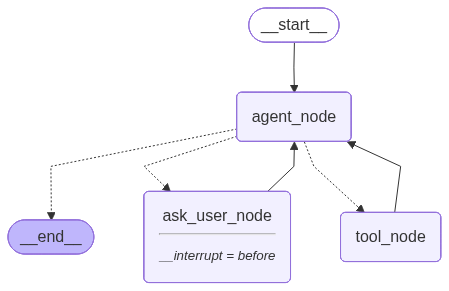

In [7]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph:", e)


In [8]:
# lager en query som spø om mere informasjon

user_input = "Hvordan er  været? "


config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    if "messages" in event:
       event["messages"][-1].pretty_print()

================================ Human Message =================================

Hvordan er  været? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (e7c98ee7-6e4b-4340-b44e-364a47953ce4)
 Call ID: e7c98ee7-6e4b-4340-b44e-364a47953ce4
  Args:
    query: Hvordan er vejret?
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "TV 2 Vejr | Se vejret i dag, i morgen og 7 dage frem - TV 2", "url": "https://vejr.tv2.dk", "content": "Klima\n\n## Stort vulkanudbrud overrasker forskere efter nye målinger\n\nVejr\n\n## Historisk hedebølge hærger Europa – og nu bliver det endnu varmere\n\nVejr\n\n## Sol og tørvejr resten af måneden\n\nVejr\n\n## Her kan det blive op til 25 grader\n\nVejr\n\n## Årets første store hedebølge er på vej til Europa\n\nVejr\n\n## Festivalerne starter nu – og de har vejret med sig\n\nVejr\n\n## Varmen vender tilbage – op mod 

In [9]:
from langchain_core.messages import ToolMessage

tool_call_id = snapshot.values["messages"][-1].tool_calls[0]["id"]

user_response = ToolMessage(
    content=" i Oslo",
    tool_call_id=tool_call_id
)

graph.update_state(config, {"messages": [user_response]},
                   as_node="ask_user_node")



NameError: name 'snapshot' is not defined

In [ ]:
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)

for event in events:
    if "messages" in event:
       event["messages"][-1].pretty_print()

================================ Human Message =================================

Jeg trenger å vite noe, men jeg trenger ditt input først
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (2c8d122e-b11b-424d-b3c2-f34486f99307)
 Call ID: 2c8d122e-b11b-424d-b3c2-f34486f99307
  Args:
    query: Jeg trenger å vite noe, men jeg trenger ditt input først
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Hva betyr det å vite noe? : r/askphilosophy - Reddit", "url": "https://www.reddit.com/r/askphilosophy/comments/3zh5sr/what_does_it_mean_to_know_something?tl=no", "content": "Veldig kort startversjon: Hvis jeg vet noe, så må jeg tro det, jeg må ha grunn til å tro det, og det må være sant. Så kunnskap er bare en måte å", "score": 0.21290259}, {"title": "viten – Store norske leksikon", "url": "https://snl.no/viten", "content": "Spørsmålet om hva det